In [3]:
import os
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader

# KoBERT 및 Transformers 관련
from kobert_tokenizer import KoBERTTokenizer 
from transformers import (
    AutoModelForSequenceClassification,
    get_linear_schedule_with_warmup,
    AdamW # 최적화 함수
)

# 평가 및 데이터 분할
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report

# 실험 기록 (W&B)
import wandb 

import warnings
warnings.filterwarnings('ignore')

In [4]:
# 1. 재현성을 위한 시드 고정

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    # CuDNN 결정론적 설정 (재현성 강화)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

In [8]:
# 2. GPU 확인
print(torch.cuda.is_available())
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('사용 디바이스:', device)
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    # VRAM 성능을 활용하기 위해 정보 출력
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')

True
사용 디바이스: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.6 GB


In [6]:
# 3. KoBERT 설정
model_name = 'skt/kobert-base-v1'
tokenizer = KoBERTTokenizer.from_pretrained(model_name)

The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'XLNetTokenizer'. 
The class this function is called from is 'KoBERTTokenizer'.


In [14]:
# ============================
# 실험 설정값 (KoBERT 최적화)
# ============================
CONFIG = {
    # 1. 모델 설정
    'model_name': 'skt/kobert-base-v1', # KoBERT 공식 모델명
    'num_labels': 5,                   # 분류할 클래스 개수 (협박, 갈취 등 5종)

    # 2. 데이터 경로 (본인의 환경에 맞게 수정 필요)
    # 윈도우 환경이라면 'C:/Users/sr/...' 처럼 절대경로를 쓰는 것이 안전합니다.
    'data_path': 'data/train_full.csv', 
    'test_path': 'data/test.csv',
    'save_dir': 'model/kobert_f1_comparison',

    # 3. 토크나이저 및 문장 길이
    'max_length': 512, 

    # 4. 학습 하이퍼파라미터
    'epochs': 5,
    'batch_size': 32,         # 배치를 32로 설정하여 학습 속도와 안정성을 확보합니다.
    'learning_rate': 3e-5,    # BERT 전이학습 권장 학습률
    'warmup_ratio': 0.1,      # 초기 학습 안정화를 위한 웜업 비율
    'val_ratio': 0.1,         # 검증 데이터셋 비율 (10%)

    # 5. 실험 기록 및 관리
    'use_wandb': True,        # W&B 사용 여부
    'project_name': 'DKTC-DLthon',
    'run_name': 'KoBERT-base-F1-v1'
}

# 저장 디렉토리 생성
os.makedirs(CONFIG['save_dir'], exist_ok=True)

# 6. 레이블 매핑 (제공해주신 데이터 기준)
LABEL_MAP = {
    '협박 대화': 0,
    '갈취 대화': 1,
    '직장 내 괴롭힘 대화': 2,
    '기타 괴롭힘 대화': 3,
    '일상 대화': 4
}
ID2LABEL = {v: k for k, v in LABEL_MAP.items()}

print('✅ 실험 설정값 확인:')
for k, v in CONFIG.items():
    print(f'  {k}: {v}')

✅ 실험 설정값 확인:
  model_name: skt/kobert-base-v1
  num_labels: 5
  data_path: data/train_full.csv
  test_path: data/test.csv
  save_dir: model/kobert_f1_comparison
  max_length: 512
  epochs: 5
  batch_size: 32
  learning_rate: 3e-05
  warmup_ratio: 0.1
  val_ratio: 0.1
  use_wandb: True
  project_name: DKTC-DLthon
  run_name: KoBERT-base-F1-v1


In [15]:
# 데이터 로드
df = pd.read_csv(CONFIG['data_path'])
test_df = pd.read_csv(CONFIG['test_path'])

print('전체 학습 데이터:', df.shape)
print('테스트 데이터:', test_df.shape)
print()
print('클래스 분포:')
print(df['class'].value_counts())

전체 학습 데이터: (4949, 4)
테스트 데이터: (500, 2)

클래스 분포:
class
기타 괴롭힘 대화      1094
일상 대화           999
갈취 대화           981
직장 내 괴롭힘 대화     979
협박 대화           896
Name: count, dtype: int64


In [16]:
# train / validation 분할 (stratify로 클래스 비율 유지)
train_df, val_df = train_test_split(
    df,
    test_size=CONFIG['val_ratio'],
    random_state=42,
    stratify=df['label']
)

train_df = train_df.reset_index(drop=True)
val_df   = val_df.reset_index(drop=True)

print(f'학습 데이터: {len(train_df)}개')
print(f'검증 데이터: {len(val_df)}개')

학습 데이터: 4454개
검증 데이터: 495개


In [18]:
from kobert_tokenizer import KoBERTTokenizer

# 토크나이저 로드
print(f'토크나이저 로딩 중... ({CONFIG["model_name"]})')
# KoBERT 전용 토크나이저 클래스를 사용합니다.
tokenizer = KoBERTTokenizer.from_pretrained(CONFIG['model_name'])
print('토크나이저 로딩 완료!')

# 토크나이저 동작 확인
test_sentence = '안녕하세요, 현재 KoBERT로 협박 대화 분류 테스트 중입니다.'

sample = tokenizer(
    test_sentence,
    max_length=CONFIG['max_length'],
    truncation=True,
    padding='max_length',
    return_tensors='pt'
)

print('\n[토크나이저 테스트 결과]')
print('1. 토큰화 결과:', tokenizer.tokenize(test_sentence))
print('2. 토크나이저 출력 shape:', sample['input_ids'].shape)
print('3. 첫 5개 토큰 IDs:', sample['input_ids'][0][:5].tolist())

토크나이저 로딩 중... (skt/kobert-base-v1)


The tokenizer class you load from this checkpoint is not the same type as the class this function is called from. It may result in unexpected tokenization. 
The tokenizer class you load from this checkpoint is 'XLNetTokenizer'. 
The class this function is called from is 'KoBERTTokenizer'.


토크나이저 로딩 완료!

[토크나이저 테스트 결과]
1. 토큰화 결과: ['▁안', '녕', '하세요', ',', '▁현재', '▁K', 'o', 'B', 'ER', 'T', '로', '▁협박', '▁대화', '▁분류', '▁테스트', '▁중', '입니다', '.']
2. 토크나이저 출력 shape: torch.Size([1, 512])
3. 첫 5개 토큰 IDs: [2, 3135, 5724, 7814, 46]


In [20]:
# 1. Dataset 클래스 정의
class DKTCDataset(Dataset):
    def __init__(self, dataframe, tokenizer, max_length, is_test=False):
        self.data       = dataframe
        self.tokenizer  = tokenizer
        self.max_length = max_length
        self.is_test    = is_test

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # 대화 내용 추출
        text = str(self.data['conversation'].iloc[idx])

        # KoBERT 토크나이저 사용 (return_tensors='pt' 사용 시 squeeze() 필요)
        encoding = self.tokenizer(
            text,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

        item = {
            'input_ids':      encoding['input_ids'].squeeze(0),      # (1, seq_len) -> (seq_len)
            'attention_mask': encoding['attention_mask'].squeeze(0), # (1, seq_len) -> (seq_len)
        }

        # 테스트 데이터가 아닐 경우에만 라벨을 추가
        if not self.is_test:
            item['labels'] = torch.tensor(self.data['label'].iloc[idx], dtype=torch.long)

        return item


# 2. Dataset 생성
train_dataset = DKTCDataset(train_df, tokenizer, CONFIG['max_length'])
val_dataset   = DKTCDataset(val_df,   tokenizer, CONFIG['max_length'])
test_dataset  = DKTCDataset(test_df,  tokenizer, CONFIG['max_length'], is_test=True)

# 3. DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=CONFIG['batch_size'], shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG['batch_size'], shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=CONFIG['batch_size'], shuffle=False)

print(f'데이터로더 구성 완료')
print(f' - train_loader 배치 수: {len(train_loader)}')
print(f' - val_loader   배치 수: {len(val_loader)}')
print(f' - test_loader  배치 수: {len(test_loader)}')

데이터로더 구성 완료
 - train_loader 배치 수: 140
 - val_loader   배치 수: 16
 - test_loader  배치 수: 16


In [22]:
from transformers import AutoModelForSequenceClassification

print(f"모델 로딩 중... ({CONFIG['model_name']})")

# 1. 모델 로드
# num_labels는 CONFIG['num_labels'](5개)를 따릅니다.
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=CONFIG['num_labels']
)

# 2. 모델을 GPU로 이동
model = model.to(device)
print('✅ 모델 로딩 및 GPU 이동 완료!')

# 3. 파라미터 수 확인
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'──────────────────────────────────────────────────')
print(f'▶ 전체 파라미터: {total_params:,}개')
print(f'▶ 학습 파라미터: {trainable_params:,}개 (Full Fine-tuning)')
print(f'▶ 사용 디바이스: {device}')
print(f'──────────────────────────────────────────────────')

모델 로딩 중... (skt/kobert-base-v1)


Some weights of BertForSequenceClassification were not initialized from the model checkpoint at skt/kobert-base-v1 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


✅ 모델 로딩 및 GPU 이동 완료!
──────────────────────────────────────────────────
▶ 전체 파라미터: 92,190,725개
▶ 학습 파라미터: 92,190,725개 (Full Fine-tuning)
▶ 사용 디바이스: cuda
──────────────────────────────────────────────────


In [23]:
# 1. Optimizer 설정
# CONFIG에 weight_decay를 따로 넣지 않으셨다면 기본값 0.01을 유지합니다.
optimizer = AdamW(
    model.parameters(),
    lr=CONFIG['learning_rate'],
    weight_decay=0.01  # 모델 가중치 과적합 방지를 위한 규제
)

# 2. Scheduler 설정 (Warmup 전략)
# 전체 학습 스텝 = (배치 수) * (에폭 수)
total_steps  = len(train_loader) * CONFIG['epochs']
warmup_steps = int(total_steps * CONFIG['warmup_ratio'])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=warmup_steps,
    num_training_steps=total_steps
)

print(f'──────────────────────────────────────────────────')
print(f'▶ 전체 학습 스텝: {total_steps}')
print(f'▶ Warmup 스텝:   {warmup_steps}')
print(f'──────────────────────────────────────────────────')

# 3. W&B 초기화
if CONFIG['use_wandb']:
    import wandb
    # reinit=True를 추가하면 여러 번 실험할 때 충돌을 방지합니다.
    wandb.init(
        project=CONFIG['project_name'],
        name=CONFIG['run_name'],
        config=CONFIG,
        reinit=True 
    )
    print('✅ W&B 초기화 및 대시보드 연결 완료')

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

──────────────────────────────────────────────────
▶ 전체 학습 스텝: 700
▶ Warmup 스텝:   70
──────────────────────────────────────────────────


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\sr\_netrc
wandb: Currently logged in as: srbae7115 (srbae7115-sr) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin
wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


✅ W&B 초기화 및 대시보드 연결 완료


In [24]:
from tqdm.auto import tqdm

def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []
    
    # tqdm을 추가하여 실시간 학습 진행률을 확인합니다.
    progress_bar = tqdm(loader, desc="[Train]", leave=False)

    for batch in progress_bar:
        input_ids      = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels         = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss    = outputs.loss
        loss.backward()

        # Gradient Clipping: 가중치 폭주 방지 (안정적인 학습)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        
        # 예측값 추출
        preds = outputs.logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())
        
        # 진행 바에 현재 실시간 Loss 표시
        progress_bar.set_postfix({'loss': f'{loss.item():.4f}'})

    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    return avg_loss, f1


def eval_epoch(model, loader, device):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []
    
    # 검증 시에는 tqdm 진행 바를 파란색 등으로 구분하면 보기 편합니다.
    progress_bar = tqdm(loader, desc="[Valid]", leave=False)

    with torch.no_grad():
        for batch in progress_bar:
            input_ids      = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels         = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()

            preds = outputs.logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(loader)
    f1 = f1_score(all_labels, all_preds, average='macro')
    
    return avg_loss, f1, all_preds, all_labels

In [25]:
best_val_f1   = 0
best_epoch    = 0
history       = []

# 저장 경로 생성
os.makedirs(CONFIG['save_dir'], exist_ok=True)

print('=' * 60)
print(f'🚀 {CONFIG["run_name"]} 학습 시작!')
print('=' * 60)

for epoch in range(1, CONFIG['epochs'] + 1):
    print(f'\n[Epoch {epoch}/{CONFIG["epochs"]}]')

    # 1. 학습 및 검증 진행
    train_loss, train_f1 = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss, val_f1, val_preds, val_labels = eval_epoch(model, val_loader, device)

    # 2. 결과 출력
    print(f'  ▶ Train Loss: {train_loss:.4f} | Train F1: {train_f1:.4f}')
    print(f'  ▶ Val   Loss: {val_loss:.4f} | Val   F1: {val_f1:.4f}')

    # 3. 데이터 기록 (Local & W&B)
    epoch_results = {
        'epoch': epoch,
        'train_loss': train_loss, 'train_f1': train_f1,
        'val_loss': val_loss,     'val_f1': val_f1
    }
    history.append(epoch_results)

    if CONFIG['use_wandb']:
        wandb.log(epoch_results)

    # 4. Best Model 저장 (F1-score 기준)
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_epoch  = epoch
        
        # 모델과 토크나이저를 하나의 폴더에 저장 (나중에 AutoModel로 로드 가능)
        model.save_pretrained(CONFIG['save_dir'])
        tokenizer.save_pretrained(CONFIG['save_dir'])
        
        print(f'  ★ Best model saved! (Val F1: {best_val_f1:.4f})')

    # 메모리 정리 (VRAM 확보)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print('\n' + '=' * 60)
print(f'✅ 학습 완료!')
print(f'▶ Best Epoch: {best_epoch}')
print(f'▶ Best Val F1: {best_val_f1:.4f}')
print('=' * 60)

if CONFIG['use_wandb']:
    # 학습 종료 후 최종 성적 리포트 작성
    wandb.run.summary["best_val_f1"] = best_val_f1
    wandb.run.summary["best_epoch"] = best_epoch
    wandb.finish()

🚀 KoBERT-base-F1-v1 학습 시작!

[Epoch 1/5]


[Train]:   0%|          | 0/140 [00:00<?, ?it/s]

[Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

  ▶ Train Loss: 0.9612 | Train F1: 0.6569
  ▶ Val   Loss: 0.4160 | Val   F1: 0.8656
  ★ Best model saved! (Val F1: 0.8656)

[Epoch 2/5]


[Train]:   0%|          | 0/140 [00:00<?, ?it/s]

...

[Valid]:   0%|          | 0/16 [00:00<?, ?it/s]

  ▶ Train Loss: 0.0604 | Train F1: 0.9867
  ▶ Val   Loss: 0.2692 | Val   F1: 0.9215


wandb: ERROR The nbformat package was not found. It is required to save notebook history.



✅ 학습 완료!
▶ Best Epoch: 3
▶ Best Val F1: 0.9257


epoch,▁▃▅▆█
train_f1,▁▆▇██
train_loss,█▃▂▁▁
val_f1,▁▄█▇█
val_loss,█▅▁▃▂
best_epoch,3
best_val_f1,0.92567
epoch,5
train_f1,0.98669
train_loss,0.06035
val_f1,0.9215


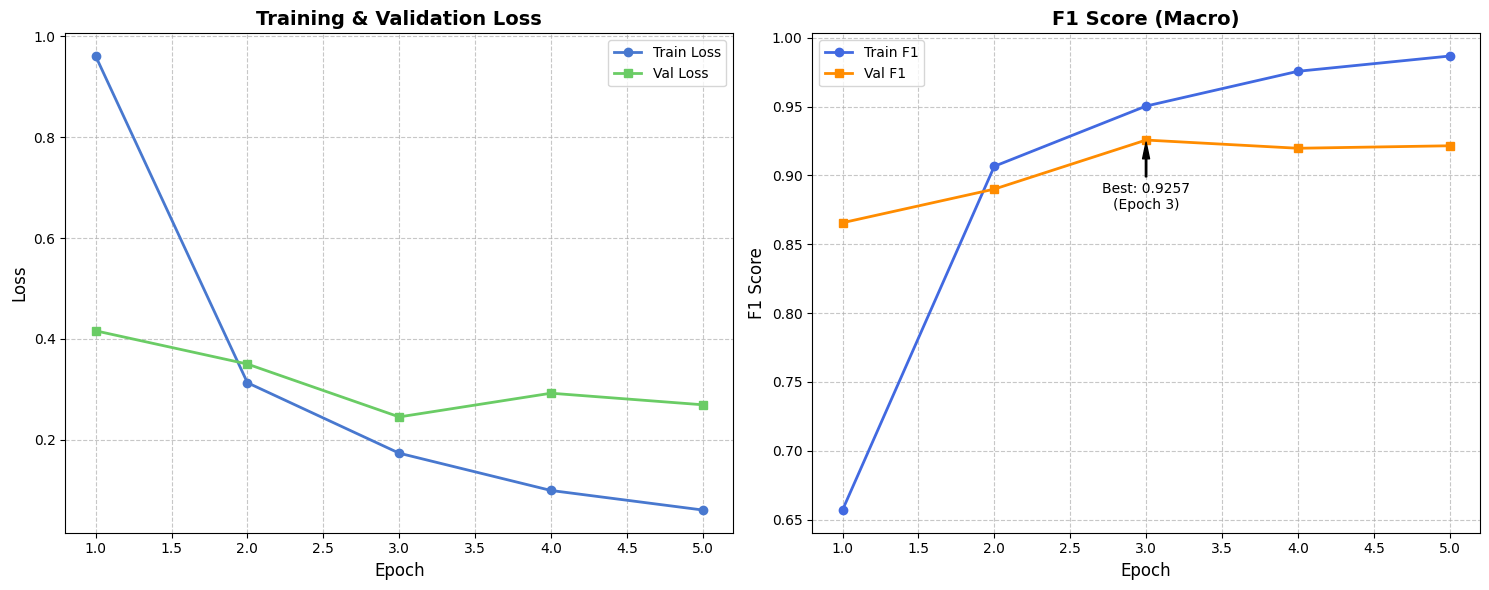

✅ 그래프가 다음 경로에 저장되었습니다: model/kobert_f1_comparison\training_history_plot.png


In [27]:
import matplotlib.pyplot as plt

# 1. 결과 데이터프레임 변환
history_df = pd.DataFrame(history)

# 2. 저장 폴더 확인 (save_dir 내에 저장하도록 변경)
save_path = os.path.join(CONFIG['save_dir'], 'training_history_plot.png')

# 3. 그래프 스타일 및 폰트 설정
plt.style.use('seaborn-v0_8-muted') # 깔끔한 테마 적용
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- 왼쪽: Loss 그래프 ---
axes[0].plot(history_df['epoch'], history_df['train_loss'], 'o-', label='Train Loss', linewidth=2)
axes[0].plot(history_df['epoch'], history_df['val_loss'], 's-', label='Val Loss', linewidth=2)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.7)

# --- 오른쪽: F1 Score 그래프 ---
axes[1].plot(history_df['epoch'], history_df['train_f1'], 'o-', label='Train F1', linewidth=2, color='royalblue')
axes[1].plot(history_df['epoch'], history_df['val_f1'], 's-', label='Val F1', linewidth=2, color='darkorange')

# 최고 성능 지점 표시 (Best F1)
best_f1_val = history_df['val_f1'].max()
best_f1_epoch = history_df.loc[history_df['val_f1'].idxmax(), 'epoch']
axes[1].annotate(f'Best: {best_f1_val:.4f}\n(Epoch {int(best_f1_epoch)})', 
                 xy=(best_f1_epoch, best_f1_val), 
                 xytext=(best_f1_epoch, best_f1_val - 0.05),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5),
                 ha='center')

axes[1].set_title('F1 Score (Macro)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('F1 Score', fontsize=12)
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.7)

# 전체 레이아웃 조정 및 저장
plt.tight_layout()
plt.savefig(save_path, dpi=200, bbox_inches='tight')
plt.show()

print(f'✅ 그래프가 다음 경로에 저장되었습니다: {save_path}')

In [30]:

# 1. 최적의 모델 불러오기 (이미 메모리에 있지만, 확실히 하기 위해 저장된 것을 로드)
print("최고 성능 모델 로드 중...")
model = AutoModelForSequenceClassification.from_pretrained("model/kobert_f1_comparison")
model.to(device)
model.eval()

# 2. 테스트 데이터 예측 진행
test_preds = []

print("테스트 데이터 예측 시작...")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="[Predicting]"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        preds = torch.argmax(logits, dim=1).cpu().numpy()
        test_preds.extend(preds)

# 3. submission.csv 파일 불러와서 채우기
submission = pd.read_csv('data/submission_kobert.csv') 

# 예측값 채워넣기 (0~4 사이의 숫자가 들어갑니다)
submission['class'] = test_preds

# 4. 최종 결과 저장
submission_file_name = f"submission_{CONFIG['run_name']}_f1_{best_val_f1:.4f}.csv"
submission.to_csv(submission_file_name, index=False)

print(f"✅ 제출 파일 생성 완료: {submission_file_name}")
print(submission.head()) # 상위 5개 미리보기

최고 성능 모델 로드 중...
테스트 데이터 예측 시작...


[Predicting]:   0%|          | 0/16 [00:00<?, ?it/s]

✅ 제출 파일 생성 완료: submission_KoBERT-base-F1-v1_f1_0.9257.csv
     idx  class
0  t_000      1
1  t_001      2
2  t_002      2
3  t_003      3
4  t_004      3


In [33]:
import torch.nn.functional as F

# --- 설정값 (원하는 수치로 조정하세요) ---
THRESHOLD = 0.6  # 0.6 미만 확신 시 일상 대화(4)로 분류
NORMAL_CLASS = 4
# ---------------------------------------

# 1. 최적의 모델 불러오기
print("최고 성능 모델 로드 중...")
model = AutoModelForSequenceClassification.from_pretrained(CONFIG['save_dir'])
model.to(device)
model.eval()

# 2. 테스트 데이터 예측 진행 (Threshold 적용)
test_preds = []
confidence_scores = [] # 나중에 분석을 위해 저장

print(f"테스트 데이터 예측 시작... (Threshold: {THRESHOLD})")
with torch.no_grad():
    for batch in tqdm(test_loader, desc="[Predicting]"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        
        # 확률값으로 변환 (Softmax)
        probs = F.softmax(logits, dim=1)
        
        # 가장 높은 확률과 해당 인덱스(클래스) 추출
        max_probs, preds = torch.max(probs, dim=1)
        
        # CPU로 옮겨서 리스트화
        max_probs = max_probs.cpu().numpy()
        preds = preds.cpu().numpy()

        # Threshold 로직 적용
        for prob, pred in zip(max_probs, preds):
            # 예측이 0~3(폭력)인데 확신(prob)이 낮으면 일상(4)으로 변경
            if pred < NORMAL_CLASS and prob < THRESHOLD:
                test_preds.append(NORMAL_CLASS)
            else:
                test_preds.append(pred)
            confidence_scores.append(prob)

# 3. submission.csv 파일 불러와서 채우기
# 파일 경로가 'data/test.csv'의 짝인 'data/submission.csv'인지 확인 필요
submission = pd.read_csv('data/submission.csv') 

# 예측값 채워넣기
submission['class'] = test_preds

# 4. 최종 결과 저장 (파일명에 Threshold 정보 추가)
submission_file_name = f"submission_{CONFIG['run_name']}_f1_{best_val_f1:.4f}_th_{THRESHOLD}.csv"
submission.to_csv(submission_file_name, index=False)

print("-" * 30)
print(f"✅ 제출 파일 생성 완료: {submission_file_name}")
print(f"📊 클래스별 분포:\n{submission['class'].value_counts().sort_index()}")
print(f"💡 평균 확신도(Confidence): {sum(confidence_scores)/len(confidence_scores):.4f}")
print("-" * 30)
print(submission.head())

최고 성능 모델 로드 중...
테스트 데이터 예측 시작... (Threshold: 0.6)


[Predicting]:   0%|          | 0/16 [00:00<?, ?it/s]

------------------------------
✅ 제출 파일 생성 완료: submission_KoBERT-base-F1-v1_f1_0.9257_th_0.6.csv
📊 클래스별 분포:
class
0     98
1    103
2    122
3    156
4     21
Name: count, dtype: int64
💡 평균 확신도(Confidence): 0.9286
------------------------------
     idx  class
0  t_000      1
1  t_001      2
2  t_002      2
3  t_003      3
4  t_004      3


In [35]:
# 1. 테스트 데이터 원문 불러오기 (경로를 본인의 환경에 맞게 확인하세요)
test_df = pd.read_csv('data/test.csv') 

# 2. 예측 결과와 원문을 합친 분석용 데이터프레임 생성
analysis_df = pd.DataFrame({
    'text': test_df['conversation'],
    'pred_class': test_preds,
    'confidence': confidence_scores  # 아까 저장한 확신도 점수
})

# 3. Class 4(일상 대화)로 분류된 샘플만 필터링
normal_samples = analysis_df[analysis_df['pred_class'] == 4]

print(f"📊 전체 {len(test_preds)}건 중 일상 대화로 분류된 건수: {len(normal_samples)}건")
print("-" * 50)

# 4. 상위 10개 예시 문장 출력
if len(normal_samples) > 0:
    # 확신도가 높은 순서대로 5개, 낮은 순서대로 5개 보여주면 분석에 더 좋습니다.
    print("✅ [확신도 높은 일상 대화 예시]")
    display(normal_samples.sort_values(by='confidence', ascending=False).head(5))
    
    print("\n⚠️ [확신도 낮은 일상 대화 예시 - THRESHOLD에 의해 걸러진 것들]")
    display(normal_samples.sort_values(by='confidence', ascending=True).head(5))
else:
    print("❌ 일상 대화로 분류된 문장이 없습니다. THRESHOLD를 더 높여보세요!")

📊 전체 500건 중 일상 대화로 분류된 건수: 21건
--------------------------------------------------
✅ [확신도 높은 일상 대화 예시]


,text,pred_class,confidence
82,"천안 두정동 제이빌라 인데요, 지금 화재가 발생했어요. 빌라 어디에 불이 났나요? ...",4,0.595216
330,야 너네 레시피 내놔 너네 누구야? 양아치야? 미쳤어? 아니 이 아저씨가 미쳤나...,4,0.590226
116,예쁜이메리크리스마쑤 아직인뎅 원래 이브에하는거거든 카드써조 카드 어제 써서보냈는데 ...,4,0.589221
11,아 취업하고 싶은데 누가 나 좀 안 데려가냐 아 그니까 나도 취업하고싶다 코로나때문...,4,0.571812
473,미연아 너 저 선배랑 친해 어 아니 친한건 아니고 그냥 가끔 얘기하는 정도 왜 저 ...,4,0.569564



⚠️ [확신도 낮은 일상 대화 예시 - THRESHOLD에 의해 걸러진 것들]


,text,pred_class,confidence
249,나한테 먼저 빌려주기로 해놓고 다른사람 먼저 빌려줘서 올해 우리집 농사 다 망하게 ...,4,0.480978
462,자네 그 사실을 자네말고 누가 알고 있나? 네? 저밖에 모릅니다 부장님 정말인가? ...,4,0.487898
295,동생아 내 방 좀 정리해줘 싫어 내가 왜 언니 방이니까 언니가 해 자매끼리 왜이래 ...,4,0.494484
261,야 죽을래 아 또 왜요 형 어제 설거지 너였잖아 아 맞다 죄송해요 아 빨리해놔 네...,4,0.500966
225,친구 선물 사줘야 되는데 뭐사주지 친구 남자야 여자야 남자 향수가 무난하지 않나 향...,4,0.501434


PCA 분석용 데이터 수집 중...


  0%|          | 0/16 [00:00<?, ?it/s]

PCA 변환 완료! 데이터 형태: (500, 2)


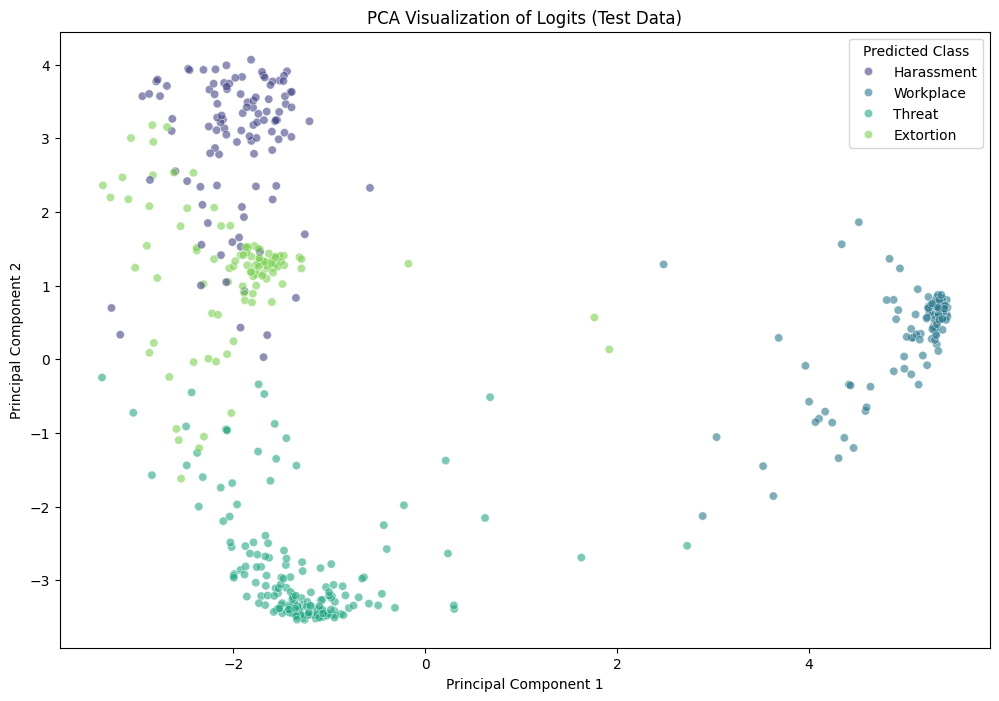

In [37]:
import numpy as np
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터를 담을 리스트 초기화
logits_list = []
test_preds = []

model.eval()
print("PCA 분석용 데이터 수집 중...")

with torch.no_grad():
    for batch in tqdm(test_loader):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        
        # [중요] 모델의 출력값(Logits)을 CPU로 옮겨서 저장합니다.
        logits = outputs.logits.cpu().numpy()
        logits_list.append(logits)
        
        # 기존 예측값 저장 (Threshold 미적용 원본)
        preds = np.argmax(logits, axis=1)
        test_preds.extend(preds)

# 2. 리스트를 하나의 큰 행렬로 합칩니다. (샘플 수, 5)
logits_array = np.vstack(logits_list)

# 3. PCA 실행 (5차원 -> 2차원)
pca = PCA(n_components=2)
pca_features = pca.fit_transform(logits_array)

print(f"PCA 변환 완료! 데이터 형태: {pca_features.shape}")

# 4. 시각화
plt.figure(figsize=(12, 8))
# 라벨 이름 매핑
label_names = {0: 'Extortion', 1: 'Harassment', 2: 'Workplace', 3: 'Threat', 4: 'Normal'}
current_labels = [label_names[p] for p in test_preds]

sns.scatterplot(
    x=pca_features[:, 0], 
    y=pca_features[:, 1], 
    hue=current_labels, 
    palette='viridis',
    alpha=0.6
)
plt.title("PCA Visualization of Logits (Test Data)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Predicted Class")
plt.show()

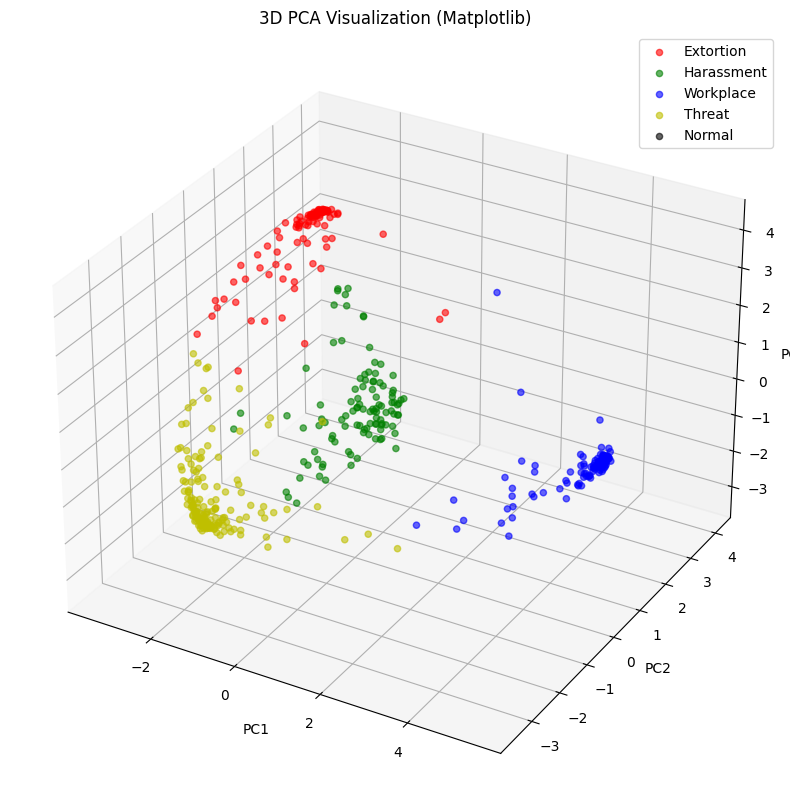

In [42]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # 3D 설정을 위한 모듈

# 1. 3차원 PCA 수행
pca_3d = PCA(n_components=3)
pca_features_3d = pca_3d.fit_transform(logits_array)

# 2. 그래프 설정
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# 클래스별 색상 및 이름 설정
colors = ['r', 'g', 'b', 'y', 'black'] # 4번(Normal)은 검은색(black)으로 설정하여 눈에 띄게 함
label_names = ['Extortion', 'Harassment', 'Workplace', 'Threat', 'Normal']

# 3. 클래스별로 루프를 돌며 점 찍기
for i in range(5):
    # 해당 클래스에 해당하는 인덱스만 추출
    idx = np.where(np.array(test_preds) == i)
    ax.scatter(pca_features_3d[idx, 0], 
               pca_features_3d[idx, 1], 
               pca_features_3d[idx, 2], 
               c=colors[i], 
               label=label_names[i], 
               alpha=0.6, 
               s=20)

ax.set_title("3D PCA Visualization (Matplotlib)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.legend()

plt.show()